# Convolution Operation and Learning Stencils
`Conv2D` from `keras` is an implementation of a convolution learner- that learns the values required in a kernel, from random initializations.
These kernels are:

* Randomly initialized (using an initializer like `glorot_uniform` or `he_normal` by default).

* Learned via backpropagation: During training, gradient descent updates the kernel weights based on how well the current feature maps help minimize the loss.

* The process is data-driven — the model discovers patterns like edges, corners, and eventually abstract concepts just by optimizing the weights in these kernels.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


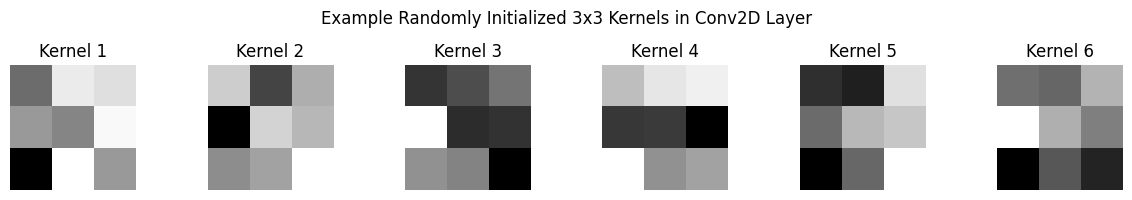

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.initializers import RandomNormal

# Create a dummy model with one Conv2D layer
model = Sequential([
    Conv2D(6, (3, 3), input_shape=(28, 28, 1), kernel_initializer=RandomNormal(mean=0.0, stddev=1.0))
])

# Extract kernel weights
kernels = model.layers[0].get_weights()[0]  # shape: (3, 3, 1, 6)

# Plot each 3x3 kernel
plt.figure(figsize=(12, 2))
for i in range(kernels.shape[-1]):
    kernel = kernels[:, :, 0, i]  # Get 2D slice for filter i
    plt.subplot(1, 6, i + 1)
    plt.imshow(kernel, cmap='gray')
    plt.title(f'Kernel {i+1}')
    plt.axis('off')

plt.suptitle("Example Randomly Initialized 3x3 Kernels in Conv2D Layer")
plt.tight_layout()
plt.show()


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Layer

class FFTLayer(Layer):
    def __init__(self, **kwargs):
        super(FFTLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        height, width = input_shape[1], input_shape[2]

        # Real and imaginary parts of learnable frequency mask
        self.freq_mask_real = self.add_weight(
            shape=(height, width),
            initializer='glorot_uniform',
            trainable=True,
            name='freq_mask_real'
        )
        self.freq_mask_imag = self.add_weight(
            shape=(height, width),
            initializer='zeros',
            trainable=True,
            name='freq_mask_imag'
        )

    def call(self, inputs):
        # Remove channel dim (assumes grayscale input)
        x = tf.squeeze(inputs, axis=-1)  # shape: (batch, height, width)
        x_complex = tf.cast(x, tf.complex64)

        # Apply FFT
        x_fft = tf.signal.fft2d(x_complex)

        # Construct complex mask and apply it
        mask = tf.complex(self.freq_mask_real, self.freq_mask_imag)
        x_filtered = x_fft * mask

        # Inverse FFT
        x_ifft = tf.signal.ifft2d(x_filtered)
        x_abs = tf.math.abs(x_ifft)

        # Add channel dim back
        return tf.expand_dims(x_abs, axis=-1)  # shape: (batch, height, width, 1)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Preprocess: reshape and normalize
x_train = x_train.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
x_test = x_test.reshape((-1, 28, 28, 1)).astype("float32") / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build a simple CNN
conv_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
conv_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
conv_history = conv_model.fit(x_train, y_train, epochs=3, batch_size=128, validation_split=0.1)

# Evaluate on test set
test_loss, test_acc = conv_model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

## Build a FFT based model
# Build model
fft_model = Sequential([
    FFTLayer(input_shape=(28, 28, 1)),  # input_shape goes here
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

fft_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
fft_history = fft_model.fit(x_train, y_train, epochs=3, batch_size=128, validation_split=0.1)

# Evaluate on test set
fft_test_loss, fft_test_acc = fft_model.evaluate(x_test, y_test)
print(f"Test Accuracy: {fft_test_acc:.4f}")

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.8530 - loss: 0.5097 - val_accuracy: 0.9748 - val_loss: 0.0955
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9725 - loss: 0.0927 - val_accuracy: 0.9835 - val_loss: 0.0660
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9834 - loss: 0.0589 - val_accuracy: 0.9860 - val_loss: 0.0550
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9770 - loss: 0.0630
Test Accuracy: 0.9833


<ipython-input-34-abc33d042662>:12: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(FFTLayer, self).__init__(**kwargs)


Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6315 - loss: 1.3909 - val_accuracy: 0.9302 - val_loss: 0.2621
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9146 - loss: 0.2982 - val_accuracy: 0.9503 - val_loss: 0.1859
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9379 - loss: 0.2151 - val_accuracy: 0.9570 - val_loss: 0.1558
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9337 - loss: 0.2096
Test Accuracy: 0.9434


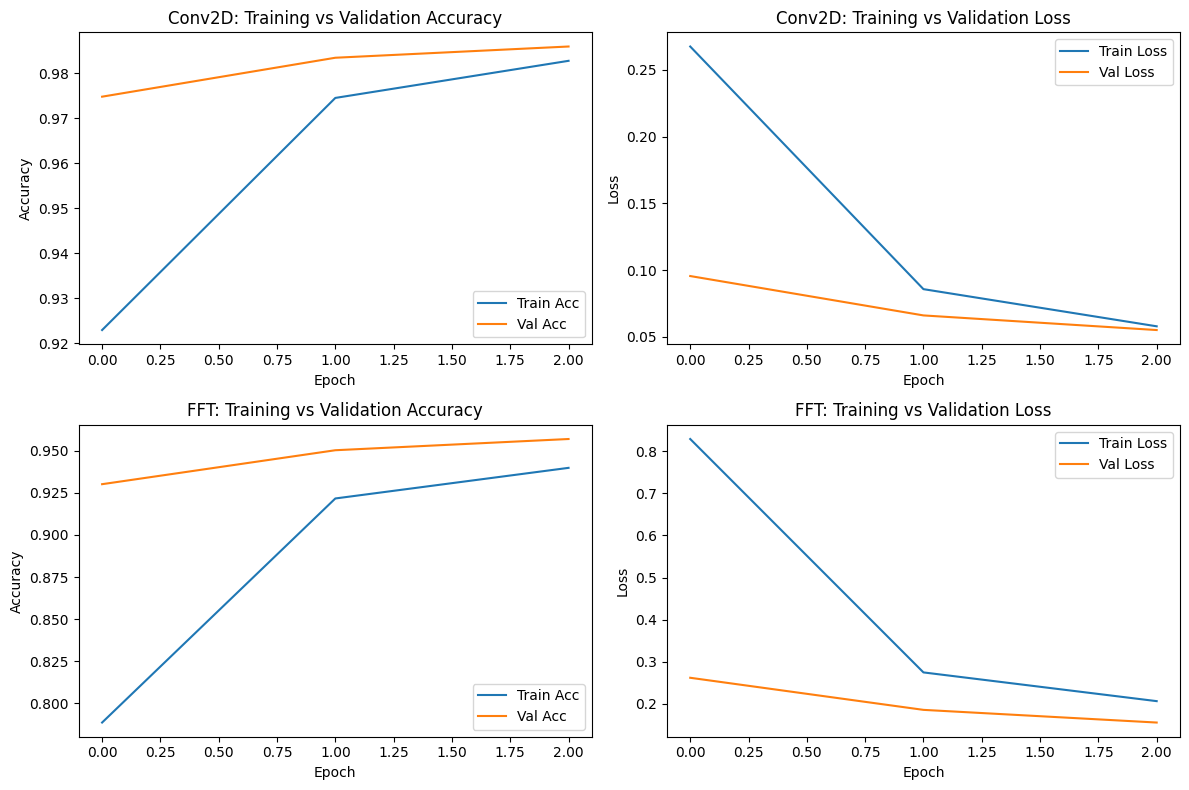

In [35]:
# Plot results side by side in 2x2 layout
plt.figure(figsize=(12, 8))

# Conv2D Accuracy
plt.subplot(2, 2, 1)
plt.plot(conv_history.history['accuracy'], label='Train Acc')
plt.plot(conv_history.history['val_accuracy'], label='Val Acc')
plt.title("Conv2D: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Conv2D Loss
plt.subplot(2, 2, 2)
plt.plot(conv_history.history['loss'], label='Train Loss')
plt.plot(conv_history.history['val_loss'], label='Val Loss')
plt.title("Conv2D: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# FFT Accuracy
plt.subplot(2, 2, 3)
plt.plot(fft_history.history['accuracy'], label='Train Acc')
plt.plot(fft_history.history['val_accuracy'], label='Val Acc')
plt.title("FFT: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# FFT Loss
plt.subplot(2, 2, 4)
plt.plot(fft_history.history['loss'], label='Train Loss')
plt.plot(fft_history.history['val_loss'], label='Val Loss')
plt.title("FFT: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
kernels = conv_model.layers[0].get_weights()[0]
print(kernels.shape)

(3, 3, 1, 32)


In [37]:
print("✅ Final Validation Accuracy (Conv2D):", conv_history.history['val_accuracy'][-1])
print("✅ Final Validation Accuracy (FFT):", fft_history.history['val_accuracy'][-1])

print("❌ Final Validation Loss (Conv2D):", conv_history.history['val_loss'][-1])
print("❌ Final Validation Loss (FFT):", fft_history.history['val_loss'][-1])


✅ Final Validation Accuracy (Conv2D): 0.9860000014305115
✅ Final Validation Accuracy (FFT): 0.9570000171661377
❌ Final Validation Loss (Conv2D): 0.05498334765434265
❌ Final Validation Loss (FFT): 0.15576259791851044


# The Stencil is a Linear Operator
When you apply a stencil (kernel, filter, weight matrix) K to every cell of a 2D field Y,you’re performing a linear transformation on the data:

$$
Y'= K *Y
$$
where ∗ denotes convolution (or correlation, depending on the implementation).

If you vectorize the field into a long column vector y, this operation can be expressed as:
$$
y' = Ay
$$
where  A is a matrix representation of the stencil — every row in A defines how the neighbors of one cell influence its transformed value.

So, convolution with a stencil is a linear map from one spatial field to another,
defined by spatially structured weights.

**In spatial modeling:**

*Convolution with normalized positive kernels* ≈ smoothing (akin to local averaging or low-pass filtering).

*Convolution with zero-sum kernels* ≈ local contrast (like semivariance or Laplacian).

*Convolution with learned kernels (in CNNs)* ≈ discovering local spatial patterns — directional, periodic, anisotropic, etc.

Rook and Queen are normalized kernels are closer to local smoothing,
but if we use unnormalized or differencing kernels, they start behaving like spatial operators that measure variability — very much like a discrete version of the graph Laplacian or semivariance operator.

| Property       | Weighted Average   | Convolution (General)         |
| -------------- | ------------------ | ----------------------------- |
| Purpose        | Smoothing          | Linear transform              |
| Kernel weights | Positive, sum to 1 | Any real values               |
| Flipping       | No                 | Yes (theoretically)           |
| Output meaning | Mean of neighbors  | Feature response / difference |
| Example        | Gaussian blur      | Laplacian, Sobel, CNN filters |


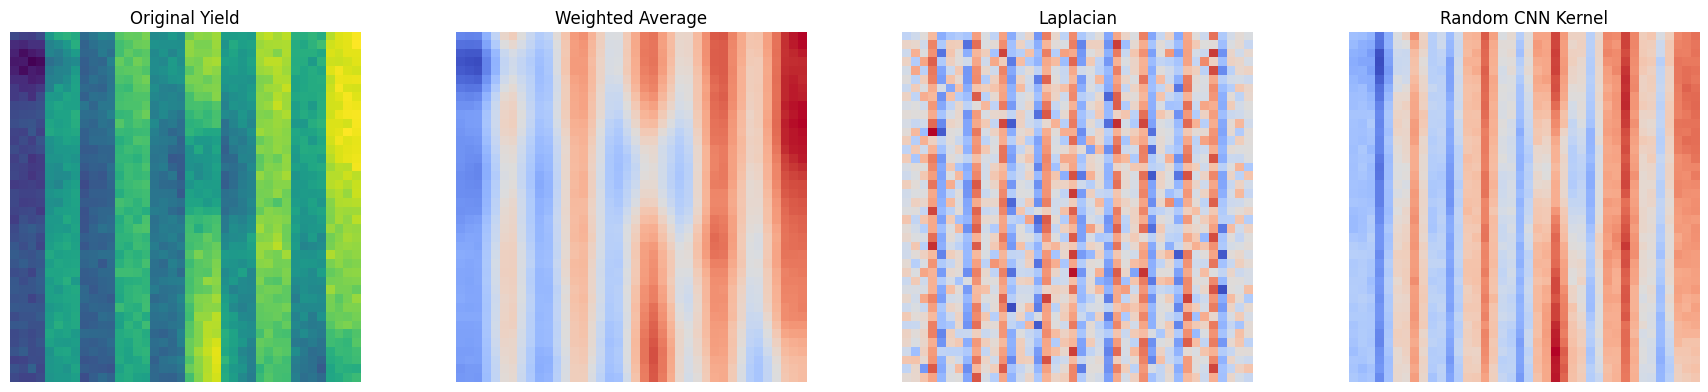

In [3]:
# --- Demonstration w/ Convolution Kernels:
# --- Mean, Laplacian, and Random CNN-like ---
import numpy as np, matplotlib.pyplot as plt, pandas as pd
np.random.seed(42)

# Synthetic field parameters
nr, nc = 40, 40
x, y = np.meshgrid(np.arange(nc), np.arange(nr))

# Generate components
y_trend = 0.6*(x/x.max()) + 0.4*(y/y.max())
stripe_w = 4
y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5
def gaussian_blob(cx, cy, sx, sy, amp):
    return amp*np.exp(-(((x-cx)**2)/(2*sx**2)+((y-cy)**2)/(2*sy**2)))
y_soil = sum(gaussian_blob(np.random.randint(0,nc), np.random.randint(0,nr),
                           np.random.uniform(2,6), np.random.uniform(2,6),
                           np.random.uniform(-1,1)) for _ in range(8))
y_noise = np.random.normal(0,0.05,(nr,nc))

# True yield surface
yield_field = 2.0 + 0.9*y_trend + 0.6*y_stripe + 0.8*y_soil + y_noise
from scipy.signal import convolve2d

kernels = {
    "Weighted Average": np.ones((3,3))/9,
    "Laplacian": np.array([[0,1,0],[1,-4,1],[0,1,0]]),
    "Random CNN Kernel": np.random.uniform(-1,1,(3,3))
}

responses = {}
for name, K in kernels.items():
    responses[name] = convolve2d(yield_field, K[::-1, ::-1], mode="same", boundary="symm")

# --- Visualization ---
fig, axs = plt.subplots(1,4,figsize=(18,4))
axs[0].imshow(yield_field, origin='lower', cmap='viridis'); axs[0].set_title("Original Yield")
for i, (name, resp) in enumerate(responses.items(), start=1):
    axs[i].imshow(resp, origin='lower', cmap='coolwarm')
    axs[i].set_title(name)
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()


| Kernel                            | Description                                           | Visual Description                               |
|-----------------------------------| ----------------------------------------------------- |--------------------------------------------------|
| **Weighted Average**              | Averages neighborhood values; smooths variation       | Smoothed, blurry surface — edges softened        |
| **Laplacian (Second Derivative)** | Computes local differences between cell and neighbors | Highlighted borders / sharp transition zones     |
| **Random CNN Kernel**             | Arbitrary weights (positive/negative)                 | Directional, stripe-like or spot features emerge |


In [ ]:
# Other examples of Stencils

Each kernel “transforms” the spatial signal to emphasize certain properties —
trend, direction, local contrast, curvature, or texture.

| Stencil                        | Transformation Type    | Interpretation                                                         |
| ------------------------------ | ---------------------- | ---------------------------------------------------------------------- |
| `np.ones((3,3))/9`             | **Low-pass filter**    | Smooths out high-frequency (fine) variation → blurring                 |
| `[[0,1,0],[1,-4,1],[0,1,0]]`   | **Laplacian operator** | Computes local curvature → enhances boundaries, detects spatial change |
| `[[1,0,-1],[1,0,-1],[1,0,-1]]` | **Sobel filter**       | Directional gradient along x-axis                                      |
| `[[0.5,-0.5],[0.5,-0.5]]`      | **Derivative filter**  | Measures spatial slope between neighboring points                      |


If you think of your field Y(x,y) as a smooth surface, then convolution with certain stencils corresponds to numerical differentiation
This is why the Laplacian filter behaves like a spatial roughness measure —
it transforms the original field into a map of how fast it’s changing in space.
| Operation                  | Continuous Analog                                                         | Discrete Stencil Example     |
| -------------------------- | ------------------------------------------------------------------------- | ---------------------------- |
| 1st derivative             | $ \frac{\partial Y}{\partial x} $                                         | `[[1,0,-1]]`                 |
| 2nd derivative (Laplacian) | $ \frac{\partial^2 Y}{\partial x^2} + \frac{\partial^2 Y}{\partial y^2} $ | `[[0,1,0],[1,-4,1],[0,1,0]]` |



When you apply a single stencil everywhere, it’s a stationary (translation-invariant) transformation- since the same rule applies to every cell.

When you use different stencils per location(variable stencil) (like in GWR or CNNs),
it becomes a non-stationary transformation — the “rule” itself changes with spatial context.

That’s why CNNs generalize this concept so powerfully: they learn what kind of transformation (what stencil shape and weights) reveals useful features.

| View        | Mathematical Form                       | Effect                  | Analogy                       |                              |
| ----------- |-----------------------------------------|-------------------------| ----------------------------- | ---------------------------- |
| Algebraic   | $ \mathbf{y}' = \mathbf{A}\mathbf{y} $  | Linear transformation   | Matrix multiplication         |                              |
| Spatial     | $ Y'(x, y) = \sum K(i, j) Y(x-i, y-j) $ | Local spatial filtering | Convolution                   |                              |
| Statistical | $ E[Y'                                  | Y] = WY $               | Weighted neighborhood average | Spatial autoregressive model |
| Physical    | $ \nabla^2 Y = 0 $                      | Diffusion / Laplacian   | Spatial equilibrium condition |                              |


In [4]:
# --- Demonstration: Stencil as Linear Transformation ---
import scipy.sparse as sp

# Select a kernel (e.g., Laplacian or Rook)
kernel = np.array([[0,1,0],
                   [1,-4,1],
                   [0,1,0]], float)   # Laplacian example

# Function to build sparse transformation matrix A
def stencil_to_matrix(kernel, nr, nc):
    """
    Construct a sparse matrix that applies a 2D convolution-like transformation
    as a linear operator (y' = A @ y).
    """
    ksize = kernel.shape[0]
    offset = ksize // 2
    rows, cols, vals = [], [], []

    def idx(r, c): return r * nc + c

    for r in range(nr):
        for c in range(nc):
            center = idx(r, c)
            for i in range(-offset, offset + 1):
                for j in range(-offset, offset + 1):
                    rr, cc = r + i, c + j
                    if 0 <= rr < nr and 0 <= cc < nc:
                        weight = kernel[i + offset, j + offset]
                        if weight != 0:
                            rows.append(center)
                            cols.append(idx(rr, cc))
                            vals.append(weight)
    A = sp.csr_matrix((vals, (rows, cols)), shape=(nr * nc, nr * nc))
    return A

A = stencil_to_matrix(kernel, nr, nc)
print(f"Transformation matrix shape: {A.shape}")
print(f"Non-zero entries: {A.nnz} (sparsity: {100*A.nnz/(nr*nc)**2:.4f}%)")

# Apply transformation as a matrix operation
y_flat = yield_field.ravel()
y_transformed = (A @ y_flat).reshape(nr, nc)

# Compare convolution vs matrix multiplication results
from scipy.signal import convolve2d
conv_result = convolve2d(yield_field, kernel[::-1, ::-1], mode='same', boundary='symm')

diff = np.abs(y_transformed - conv_result)
print(f"Max difference between matrix and convolution results: {diff.max():.3e}")


Transformation matrix shape: (1600, 1600)
Non-zero entries: 7840 (sparsity: 0.3063%)
Max difference between matrix and convolution results: 6.566e+00


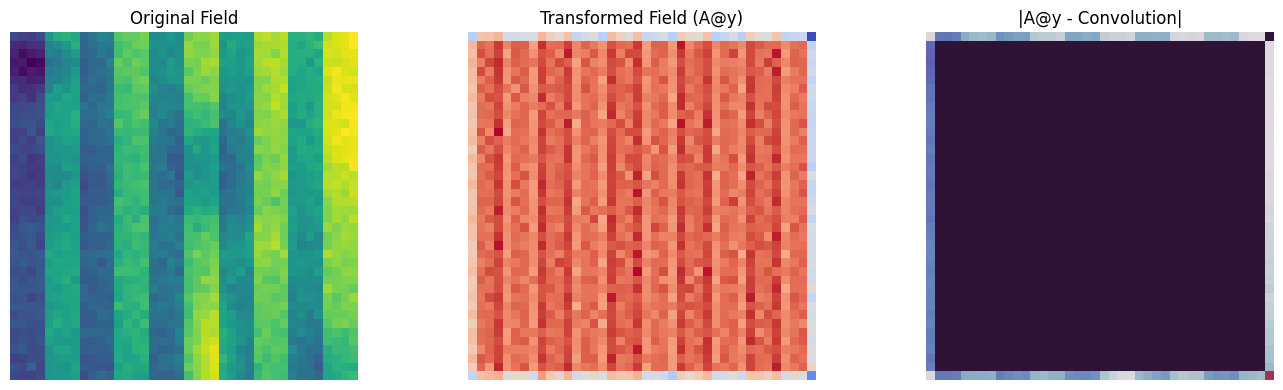

In [10]:
# Visualize the original vs transformed field
fig, axs = plt.subplots(1,3,figsize=(14,4))
axs[0].imshow(yield_field, origin='lower', cmap='viridis')
axs[0].set_title("Original Field")

axs[1].imshow(y_transformed, origin='lower', cmap='coolwarm')
axs[1].set_title("Transformed Field (A@y)")

axs[2].imshow(diff, origin='lower', cmap='twilight_shifted')
axs[2].set_title("|A@y - Convolution|")

for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()


| Aspect             | Meaning                                                             |
| ------------------ | ------------------------------------------------------------------- |
| `A`                | Encodes neighborhood connectivity + kernel weights                  |
| `A @ y`            | Applies spatial transformation linearly                             |
| **Structure of A** | Sparse, block-Toeplitz, reflects spatial adjacency                  |
| **Result**         | Local operator applied globally, yielding transformed spatial field |


 # The Inverse Operator
If applying 𝐴 transforms the original field into an enhanced one (e.g., highlighting variability), then the inverse operator $A^−1$ — if it exists or can be approximated — performs the reverse:
$$
y = A^{−1} y'
$$

- The inverse removes or “deconvolves” the transformation, restoring the smooth baseline.

- In signal processing, this is exactly what *filter inversion* does (e.g., de-blurring, de-noising).

- In spatial statistics, it’s analogous to solving for the latent smooth field behind an observed noisy pattern.

## Removing Spatial Patterns using the Inverse Stencil

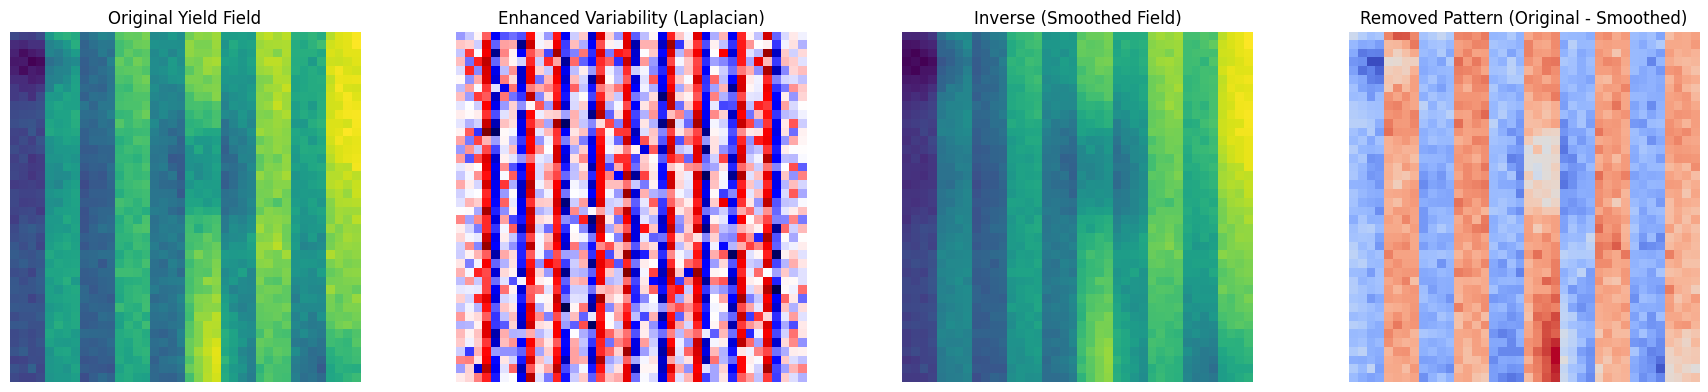

In [11]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d

np.random.seed(42)
nr, nc = 40, 40
x, y = np.meshgrid(np.arange(nc), np.arange(nr))

# --- Generate synthetic spatial components ---
y_trend = 0.6*(x/x.max()) + 0.4*(y/y.max())
stripe_w = 4
y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5

def gaussian_blob(cx, cy, sx, sy, amp):
    return amp*np.exp(-(((x-cx)**2)/(2*sx**2)+((y-cy)**2)/(2*sy**2)))

y_soil = sum(gaussian_blob(np.random.randint(0,nc), np.random.randint(0,nr),
                           np.random.uniform(2,6), np.random.uniform(2,6),
                           np.random.uniform(-1,1)) for _ in range(8))
y_noise = np.random.normal(0, 0.05, (nr,nc))

# --- Composite yield field (same as before) ---
yield_field = 2.0 + 0.9*y_trend + 0.6*y_stripe + 0.8*y_soil + y_noise

# --- Step 1: Enhance pattern using Laplacian stencil ---
lap_kernel = np.array([[0,1,0],
                       [1,-4,1],
                       [0,1,0]])
enhanced = convolve2d(yield_field, lap_kernel, mode='same', boundary='symm')

# --- Step 2: Construct Laplacian matrix for smoothing (inverse stencil) ---
coords = np.column_stack([x.ravel(), y.ravel()])
dist = cdist(coords, coords)
h = 3.0
W = np.exp(-dist**2/(2*h**2)); np.fill_diagonal(W, 0)
D = np.diag(W.sum(axis=1))
L = D - W

# Regularized inverse Laplacian smoother
lam = 1.0
y_flat = yield_field.ravel()
smoothed_flat = np.linalg.solve(D + lam*L, D @ y_flat)
smoothed = smoothed_flat.reshape(nr, nc)

# --- Step 3: Compute removed (suppressed) pattern ---
removed_pattern = yield_field - smoothed

# --- Step 4: Visualize results ---
fig, axs = plt.subplots(1,4,figsize=(18,4))
titles = [
    "Original Yield Field",
    "Enhanced Variability (Laplacian)",
    "Inverse (Smoothed Field)",
    "Removed Pattern (Original - Smoothed)"
]
fields = [yield_field, enhanced, smoothed, removed_pattern]
cmaps = ['viridis', 'seismic', 'viridis', 'coolwarm']

for ax, im, title, cmap in zip(axs, fields, titles, cmaps):
    ax.imshow(im, origin='lower', cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


The stripey [attern is still there after smoothing. How can we remove that?


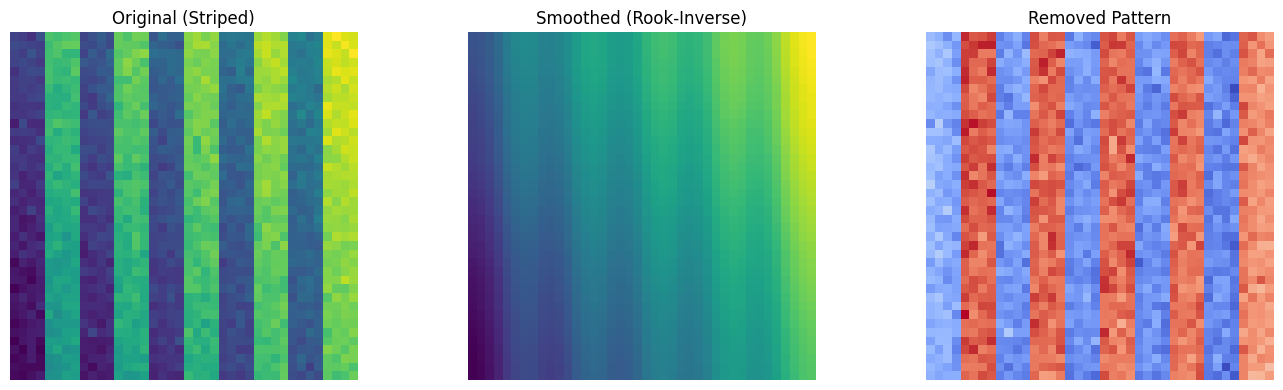

In [17]:
# Tikhonov Smoothing - removing stripes
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.random.seed(42)
nr, nc = 40, 40
x, y = np.meshgrid(np.arange(nc), np.arange(nr))

# --- Synthetic field with strong stripe component ---
y_trend  = 0.6*(x/x.max()) + 0.4*(y/y.max())
stripe_w = 4
y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5
y_noise  = np.random.normal(0,0.05,(nr,nc))
yield_field = 2.0 + 0.8*y_trend + 0.8*y_stripe + y_noise

# --- Build rook adjacency Laplacian (4-neighbors) ---
coords = np.column_stack([x.ravel(), y.ravel()])
n = nr*nc
rows, cols, vals = [], [], []
def idx(r,c): return r*nc + c
for r in range(nr):
    for c in range(nc):
        i = idx(r,c)
        for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            rr,cc = r+dr,c+dc
            if 0<=rr<nr and 0<=cc<nc:
                rows.append(i); cols.append(idx(rr,cc)); vals.append(1)
import scipy.sparse as sp
W = sp.csr_matrix((vals,(rows,cols)),shape=(n,n))
D = sp.diags(W.sum(axis=1).A1)
L = D - W   # rook Laplacian

# --- Tikhonov-regularized inverse: (I + λL)^(-1) y  ---
lam = 15.5   # adjust λ to remove more(increase the value) or less(decrease) stripes
I = sp.identity(n)
y_vec = yield_field.ravel()
y_smooth = sp.linalg.spsolve(I + lam*L, y_vec)
y_smooth = y_smooth.reshape(nr,nc)
residual = yield_field - y_smooth

# --- Visualization ---
fig, axs = plt.subplots(1,3,figsize=(14,4))
axs[0].imshow(yield_field,origin='lower',cmap='viridis'); axs[0].set_title("Original (Striped)")
axs[1].imshow(y_smooth,origin='lower',cmap='viridis'); axs[1].set_title("Smoothed (Rook-Inverse)")
axs[2].imshow(residual,origin='lower',cmap='coolwarm'); axs[2].set_title("Removed Pattern")
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()
